# Beer NBD-Dirichlet Market Share Analysis (Week 20–30)

dunnhumby "The Complete Journey" の Beer/Ale 購買データ（Week 20〜30, 全ブランド）に対して
NBD-Dirichlet モデルをベイズ推定し、マーケットシェア構造を分析する。

**モデル構造:**
1. **NBD (Negative Binomial)**: カテゴリ購買回数の異質性
2. **Dirichlet-Multinomial**: ブランド選択の異質性

**参照:** Goodhardt, Ehrenberg & Chatfield (1984), Dirichlet_MarketShare_Turing.ipynb

In [1]:
using Turing
using Distributions
using StatsPlots
using DataFrames
using SpecialFunctions   # loggamma
using MCMCChains
using StatsBase
using Random
using Printf
using SQLite

Random.seed!(42)
println("Julia version: ", VERSION)

Julia version: 1.12.5


In [2]:
# Plots 日本語フォント設定
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")

default(
  fontfamily="PlemolJP-Text",
  guidefontsize=11,
  tickfontsize=8,
  legendfontsize=8,
  margin=5Plots.mm,
)

## 1. データ読み込み — DB から Beer (Week 20–30) 購買マトリクス構築

In [3]:
DB_PATH = raw"C:\Users\kimse\OneDrive\Jupyter_notebook\dunnhumby.db"
db = SQLite.DB(DB_PATH)

# Week 20-30 全ブランドの購買データを取得
beer_raw = DBInterface.execute(db, """
    SELECT household_key, brand, COUNT(*) AS count
    FROM beer_20_30_transactions
    GROUP BY household_key, brand
    ORDER BY household_key, brand
""") |> DataFrame

SQLite.close(db)
@printf("取得行数: %d\n", nrow(beer_raw))
@printf("全ブランド数: %d\n", length(unique(beer_raw.brand)))
first(beer_raw, 10)

取得行数: 1025
全ブランド数: 54


Row,household_key,brand,count
,String,String,Int64
1,1004,2343,2
2,1005,239,1
3,1011,1728,1
4,1011,239,1
5,1014,2343,2
6,1014,239,1
7,1014,2431,1
8,1021,1728,1
9,1021,239,1


In [29]:
# 世帯×ブランド購買マトリクス（pivot）
brand_matrix = unstack(beer_raw, :household_key, :brand, :count, fill=0)

# ブランド名リスト（household_key列を除く）
brand_cols = names(brand_matrix)[2:end]
brands = ["M" * b for b in brand_cols]  # "M239" 等のラベル
J = length(brands)

# 数値マトリクスに変換
brand_counts_data = Matrix{Int}(brand_matrix[:, 2:end])
n_cat_data = vec(sum(brand_counts_data, dims=2))
N_consumers = length(n_cat_data)

@printf("消費者数:       %d\n", N_consumers)
@printf("ブランド数:     %d\n", J)
@printf("カテゴリ購買回数: min=%d  max=%d  mean=%.2f\n",
    minimum(n_cat_data), maximum(n_cat_data), mean(n_cat_data))
@printf("購買0回の消費者: %d (%.1f%%)\n",
    sum(n_cat_data .== 0), 100.0 * mean(n_cat_data .== 0))

println("\nブランド: ", brands)

消費者数:       656
ブランド数:     54
カテゴリ購買回数: min=1  max=35  mean=3.21
購買0回の消費者: 0 (0.0%)

ブランド: ["M2343", "M239", "M1728", "M2431", "M697", "M5221", "M779", "M1830", "M1767", "M5881", "M2387", "M2398", "M1649", "M1629", "M2232", "M2427", "M1920", "M40", "M5209", "M1465", "M352", "M2384", "M5392", "M1560", "M1367", "M6361", "M323", "M2572", "M2390", "M5728", "M2558", "M176", "M1283", "M1396", "M2466", "M5981", "M301", "M5751", "M2579", "M5971", "M2478", "M2426", "M6119", "M5298", "M2", "M2693", "M5120", "M5284", "M2468", "M859", "M5483", "M2556", "M2485", "M2588"]


## 2. 記述統計

In [30]:
# ブランド別 観測統計
total_purchases = sum(brand_counts_data)
share_obs = vec(sum(brand_counts_data, dims=1)) ./ total_purchases

pen_obs  = zeros(J)
freq_obs = zeros(J)
for j in 1:J
    buyers_j = brand_counts_data[:, j] .> 0
    pen_obs[j]  = mean(buyers_j)
    freq_obs[j] = sum(buyers_j) > 0 ? mean(brand_counts_data[buyers_j, j]) : 0.0
end

cat_buyers = n_cat_data .> 0
B_obs = mean(cat_buyers)

df_obs = DataFrame(
    ブランド     = brands,
    購買数       = vec(sum(brand_counts_data, dims=1)),
    シェア       = round.(share_obs, digits=3),
    浸透率       = round.(pen_obs, digits=3),
    購買頻度     = round.(freq_obs, digits=2)
)
sort!(df_obs, :シェア, rev=true)

@printf("カテゴリ浸透率: %.3f\n", B_obs)
@printf("カテゴリ平均購買回数: %.2f（全消費者）, %.2f（購買者のみ）\n",
    mean(n_cat_data), mean(n_cat_data[cat_buyers]))
@printf("総購買数: %d\n\n", total_purchases)
df_obs

カテゴリ浸透率: 1.000
カテゴリ平均購買回数: 3.21（全消費者）, 3.21（購買者のみ）
総購買数: 2104



Row,ブランド,購買数,シェア,浸透率,購買頻度
,String,Int64,Float64,Float64,Float64
1,M239,937,0.445,0.54,2.65
2,M697,471,0.224,0.302,2.38
3,M1728,180,0.086,0.149,1.84
4,M2343,69,0.033,0.075,1.41
5,M2384,50,0.024,0.059,1.28
6,M1629,46,0.022,0.029,2.42
7,M1830,37,0.018,0.053,1.06
8,M5221,26,0.012,0.037,1.08
9,M2558,25,0.012,0.027,1.39


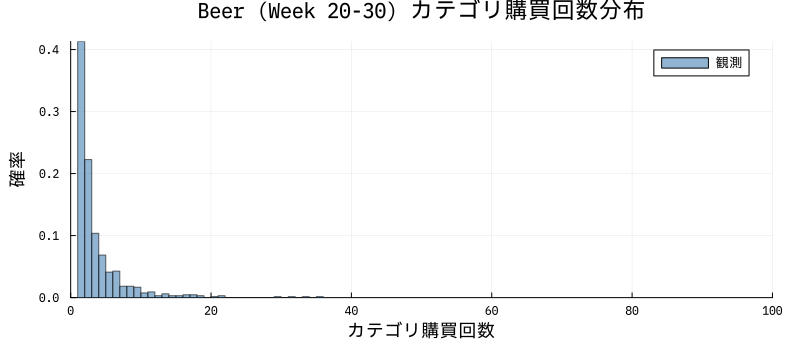

In [31]:
# カテゴリ購買回数の分布
histogram(n_cat_data; normalize=:probability,
    bins=0:maximum(n_cat_data)+1,
    label="観測", alpha=0.6, color=:steelblue,
    xlabel="カテゴリ購買回数", ylabel="確率",
    title="Beer (Week 20-30) カテゴリ購買回数分布",
    xlims =(0,100),
    size=(800, 350))

## 3. 理論値計算関数

In [32]:
"""
ブランド j の浸透率を数値的に計算する。

P(x_j=0 | N=n) = Γ(S-αj+n)·Γ(S) / [Γ(S-αj)·Γ(S+n)]
b_j = 1 - Σ_n P(N=n) · P(x_j=0 | N=n)
"""
function calc_penetration(αj::Float64, S::Float64, K::Float64, M::Float64;
                           max_n::Int=400)::Float64
    p_nb = K / (K + M)
    log_const = loggamma(S) - loggamma(S - αj)

    total_p_zero = 0.0
    for n in 0:max_n
        log_p_n = logpdf(NegativeBinomial(K, p_nb), n)
        p_n = exp(log_p_n)
        p_n < 1e-14 && n > 20 && break

        if n == 0
            p_zero_given_n = 1.0
        else
            log_p_zero = log_const + loggamma(S - αj + n) - loggamma(S + n)
            p_zero_given_n = exp(log_p_zero)
        end
        total_p_zero += p_n * p_zero_given_n
    end
    return 1.0 - total_p_zero
end

"""
購買者あたりの平均購買頻度 w_j = M·p_j / b_j
"""
function calc_avg_freq(αj::Float64, S::Float64, K::Float64, M::Float64)::Float64
    pj = αj / S
    bj = calc_penetration(αj, S, K, M)
    return bj > 0.0 ? M * pj / bj : 0.0
end

"""
カテゴリ浸透率 B = 1 - (1 + M/K)^{-K}
"""
function calc_category_penetration(K::Float64, M::Float64)::Float64
    return 1.0 - (1.0 + M / K)^(-K)
end

println("関数定義完了")

関数定義完了


## 4. Turing モデル定義

In [8]:
@model function nbd_dirichlet_model(
    n_cat::Vector{Int},
    brand_counts::Matrix{Int},
    ::Val{J}
) where {J}

    N = length(n_cat)

    # ---- 事前分布 ----
    M ~ truncated(Normal(5.0, 3.0), 0.01, 30.0)
    K ~ truncated(Normal(1.0, 0.8), 0.01, 15.0)
    S ~ truncated(Normal(1.5, 1.0), 0.01, 15.0)
    p ~ Dirichlet(J, 1.0)

    # Dirichlet パラメータ
    α = S .* p
    p_nb = K / (K + M)

    # ---- 尤度 ----
    for i in 1:N
        n_cat[i] ~ NegativeBinomial(K, p_nb)
        if n_cat[i] > 0
            brand_counts[i, :] ~ DirichletMultinomial(n_cat[i], α)
        end
    end
end

println("Turing モデル定義完了")

Turing モデル定義完了


## 5. MCMC サンプリング

In [9]:
model = nbd_dirichlet_model(n_cat_data, brand_counts_data, Val(J))

println("MCMC サンプリング開始...")
println("  サンプラー: NUTS(δ=0.65)")
println("  ウォームアップ: 500")
println("  本サンプル: 1000 × 2 チェーン")
println("  消費者数: $N_consumers, ブランド数: $J")
println("  期間: Week 20-30 (11週間)")
println()

chain = sample(model, NUTS(500, 0.65), MCMCSerial(), 1000, 2; progress=true)

println("\nサンプリング完了")

MCMC サンプリング開始...
  サンプラー: NUTS(δ=0.65)
  ウォームアップ: 500
  本サンプル: 1000 × 2 チェーン
  消費者数: 656, ブランド数: 54
  期間: Week 20-30 (11週間)



┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 1 of 2): 100%|██████████████████████████| Time: 0:05:20
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 2 of 2): 100%|██████████████████████████| Time: 0:05:25



サンプリング完了


## 6. 収束診断

In [10]:
println("=== 収束診断 ===")
println("※ R̂ ≈ 1.0 (< 1.05) であれば収束と判断")
summarize(chain)

=== 収束診断 ===
※ R̂ ≈ 1.0 (< 1.05) であれば収束と判断




  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

           M    3.2159    0.1177    0.0023   2673.4115   1417.2067    0.9999   ⋯
           K    1.8407    0.1396    0.0030   2125.0298   1336.9815    1.0008   ⋯
           S    1.6617    0.1302    0.0025   2726.2890   1428.8340    1.0009   ⋯
        p[1]    0.0410    0.0055    0.0001   2194.1092   1462.2225    1.0007   ⋯
        p[2]    0.3854    0.0152    0.0003   2935.7475   1666.9077    1.0005   ⋯
        p[3]    0.0836    0.0080    0.0001   2909.9428   1891.2918    1.0009   ⋯
        p[4]    0.0146    0.0034    0.0001   2824.6794   1149.1900    1.0002   ⋯
        p[5]    0.1856    0.0114    0.0002   2937.9795   1688.7750    1.0002   ⋯
        p[6]    0.0202    0.0042    0.0001   2747.5670   1143.6873    1.0000   ⋯
        p[7]    0.0032    0.0015    0.0000   2765.4551   1372.3383    1.0021   ⋯
        p[8]    0.0290   

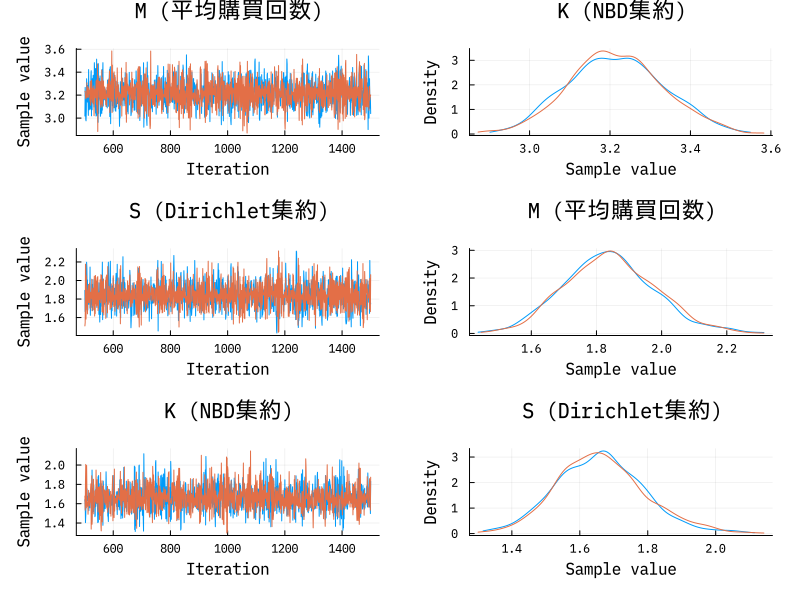

In [11]:
# トレースプロット（M, K, S）
plot(chain[["M", "K", "S"]]; layout=(3,1), size=(800, 600),
     title=["M (平均購買回数)" "K (NBD集約)" "S (Dirichlet集約)"],
     legend=false)

## 7. 事後分布

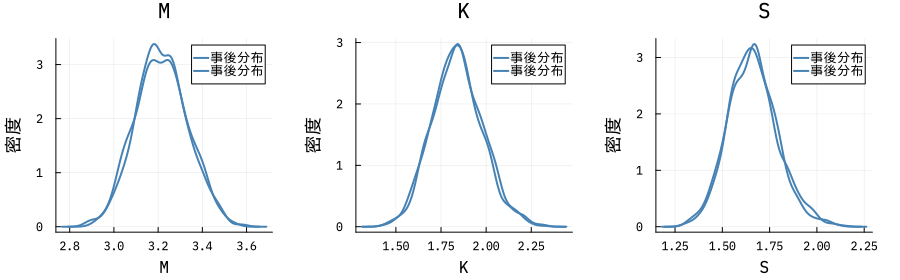

In [12]:
# 事後分布の密度プロット
density_plots = []
for param in ["M", "K", "S"]
    sym  = Symbol(param)
    vals = get(chain, sym)[sym]
    p_d  = density(vals; label="事後分布",
                   title=param, xlabel=param, ylabel="密度",
                   linewidth=2, color=:steelblue)
    push!(density_plots, p_d)
end
plot(density_plots...; layout=(1,3), size=(900, 280))


In [13]:
savefig("beer_20_30_param_posterior.png")

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\BASS_Dirichletモデル探索\\beer_20_30_param_posterior.png"

## 8. パラメータ推定結果

In [22]:
# 事後平均の取得
M_est = mean(get(chain, :M).M)
K_est = mean(get(chain, :K).K)
S_est = mean(get(chain, :S).S)

# p[1]..p[J] の取得
p_syms = namesingroup(chain, :p)
p_vals = get(chain, p_syms)
p_est  = [mean(p_vals[s]) for s in p_syms]
alpha_est = S_est .* p_est

println("=== パラメータ推定結果 (事後平均) ===\n")
@printf("M (カテゴリ平均購買回数) = %.3f\n", M_est)
@printf("K (NBD 集約パラメータ)  = %.3f\n", K_est)
@printf("S (Dirichlet 集約)      = %.3f\n", S_est)
println()

# 95% CI
for (param, sym) in [("M", :M), ("K", :K), ("S", :S)]
    vals = vec(get(chain, sym)[sym])
    q = quantile(vals, [0.025, 0.975])
    @printf("%s : %.3f  [95%% CI: %.3f, %.3f]\n", param, mean(vals), q[1], q[2])
end
println()

# ブランド別パラメータ
df_params = DataFrame(
    ブランド = brands,
    シェア_観測 = round.(share_obs, digits=3),
    シェア_推定 = round.(p_est, digits=3),
    α推定      = round.(alpha_est, digits=4)
)
sort!(df_params, :シェア_推定, rev=true)
df_params

=== パラメータ推定結果 (事後平均) ===

M (カテゴリ平均購買回数) = 3.216
K (NBD 集約パラメータ)  = 1.841
S (Dirichlet 集約)      = 1.662

M : 3.216  [95% CI: 2.997, 3.451]
K : 1.841  [95% CI: 1.580, 2.134]
S : 1.662  [95% CI: 1.423, 1.948]



Row,ブランド,シェア_観測,シェア_推定,α推定
,String,Float64,Float64,Float64
1,M239,0.445,0.385,0.6405
2,M697,0.224,0.186,0.3084
3,M1728,0.086,0.084,0.1389
4,M2343,0.033,0.041,0.0681
5,M2384,0.024,0.033,0.0541
6,M1830,0.018,0.029,0.0482
7,M5221,0.012,0.02,0.0335
8,M1629,0.022,0.016,0.0269
9,M2558,0.012,0.016,0.0258


## 9. 推定モデルの予測値 vs 観測値

In [23]:
# 推定パラメータから理論値を計算
pen_est  = [calc_penetration(α, S_est, K_est, M_est) for α in alpha_est]
freq_est = [calc_avg_freq(α, S_est, K_est, M_est) for α in alpha_est]
B_est    = calc_category_penetration(K_est, M_est)

@printf("カテゴリ浸透率: 観測=%.3f  推定=%.3f\n", B_obs, B_est)
@printf("カテゴリ平均購買回数（購買者）: 観測=%.2f  推定=%.2f\n",
    mean(n_cat_data[cat_buyers]), M_est / B_est)
println()

# 比較テーブル
df_compare = DataFrame(
    ブランド       = brands,
    シェア_観測    = round.(share_obs, digits=3),
    シェア_推定    = round.(p_est, digits=3),
    浸透率_観測    = round.(pen_obs, digits=3),
    浸透率_推定    = round.(pen_est, digits=3),
    購買頻度_観測  = round.(freq_obs, digits=2),
    購買頻度_推定  = round.(freq_est, digits=2)
)
sort!(df_compare, :シェア_観測, rev=true)
df_compare

カテゴリ浸透率: 観測=1.000  推定=0.844
カテゴリ平均購買回数（購買者）: 観測=3.21  推定=3.81



Row,ブランド,シェア_観測,シェア_推定,浸透率_観測,浸透率_推定,購買頻度_観測,購買頻度_推定
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,M239,0.445,0.385,0.54,0.505,2.65,2.46
2,M697,0.224,0.186,0.302,0.286,2.38,2.09
3,M1728,0.086,0.084,0.149,0.14,1.84,1.91
4,M2343,0.033,0.041,0.075,0.071,1.41,1.84
5,M2384,0.024,0.033,0.059,0.057,1.28,1.83
6,M1629,0.022,0.016,0.029,0.029,2.42,1.8
7,M1830,0.018,0.029,0.053,0.051,1.06,1.83
8,M5221,0.012,0.02,0.037,0.036,1.08,1.81
9,M2558,0.012,0.016,0.027,0.028,1.39,1.8


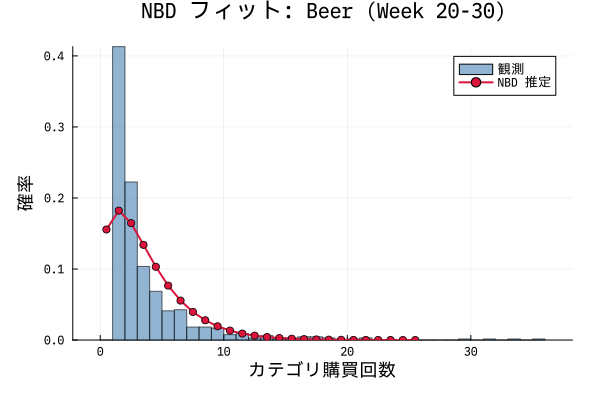

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\BASS_Dirichletモデル探索\\beer_20_30_NBD_fit.png"

In [24]:
# NBD 理論分布 vs 観測ヒストグラム
p_nb_est = K_est / (K_est + M_est)
nbd_fitted = NegativeBinomial(K_est, p_nb_est)
ns = 0:min(25, maximum(n_cat_data))

p1 = histogram(n_cat_data; normalize=:probability,
    bins=0:maximum(n_cat_data)+1,
    label="観測", alpha=0.6, color=:steelblue,
    xlabel="カテゴリ購買回数", ylabel="確率",
    title="NBD フィット: Beer (Week 20-30)")
plot!(p1, ns .+ 0.5, pdf.(nbd_fitted, ns);
    label="NBD 推定", linewidth=2, color=:crimson,
    marker=:circle, markersize=4)

display(p1)
savefig(p1,"beer_20_30_NBD_fit.png")

## 10. 浸透率・購買頻度の比較プロット

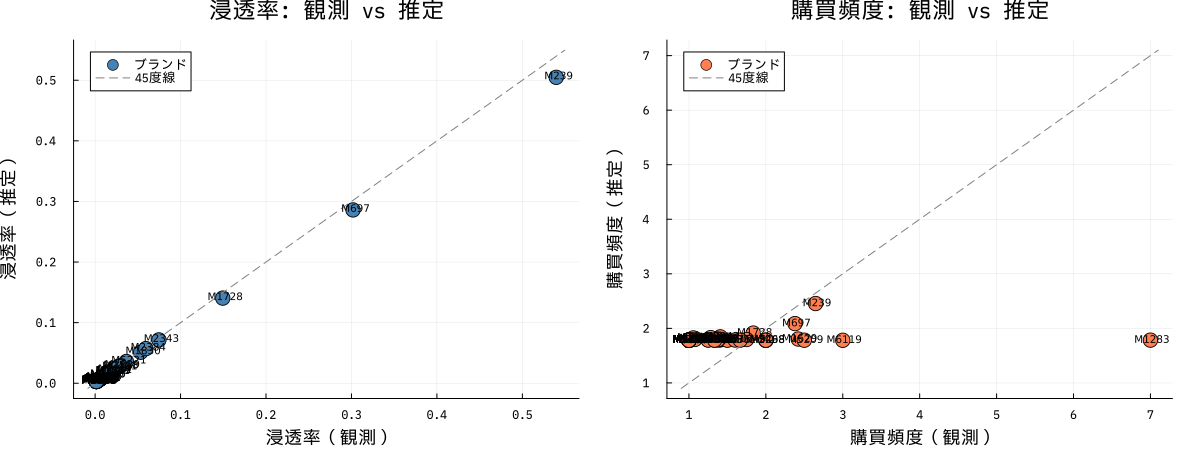

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\BASS_Dirichletモデル探索\\beer_20_30_pen_freq_compare.png"

In [25]:
# 浸透率: 観測 vs 推定
p2 = scatter(pen_obs, pen_est;
    label="ブランド", marker=:circle, markersize=8, color=:steelblue,
    xlabel="浸透率（観測）", ylabel="浸透率（推定）",
    title="浸透率: 観測 vs 推定")
for j in 1:J
    annotate!(p2, pen_obs[j]+0.003, pen_est[j]+0.003,
              text(brands[j], 7))
end
lims = extrema(vcat(pen_obs, pen_est))
plot!(p2, [lims[1]-0.01, lims[2]+0.01], [lims[1]-0.01, lims[2]+0.01];
    label="45度線", color=:gray, linestyle=:dash)

# 購買頻度: 観測 vs 推定
p3 = scatter(freq_obs, freq_est;
    label="ブランド", marker=:circle, markersize=8, color=:coral,
    xlabel="購買頻度（観測）", ylabel="購買頻度（推定）",
    title="購買頻度: 観測 vs 推定")
for j in 1:J
    annotate!(p3, freq_obs[j]+0.02, freq_est[j]+0.02,
              text(brands[j], 7))
end
lims2 = extrema(vcat(freq_obs, freq_est))
plot!(p3, [lims2[1]-0.1, lims2[2]+0.1], [lims2[1]-0.1, lims2[2]+0.1];
    label="45度線", color=:gray, linestyle=:dash)

p23=plot(p2, p3; layout=(1,2), size=(1200, 450))
display(p23); savefig(p23 , "beer_20_30_pen_freq_compare.png")


## 11. Double Jeopardy の検証

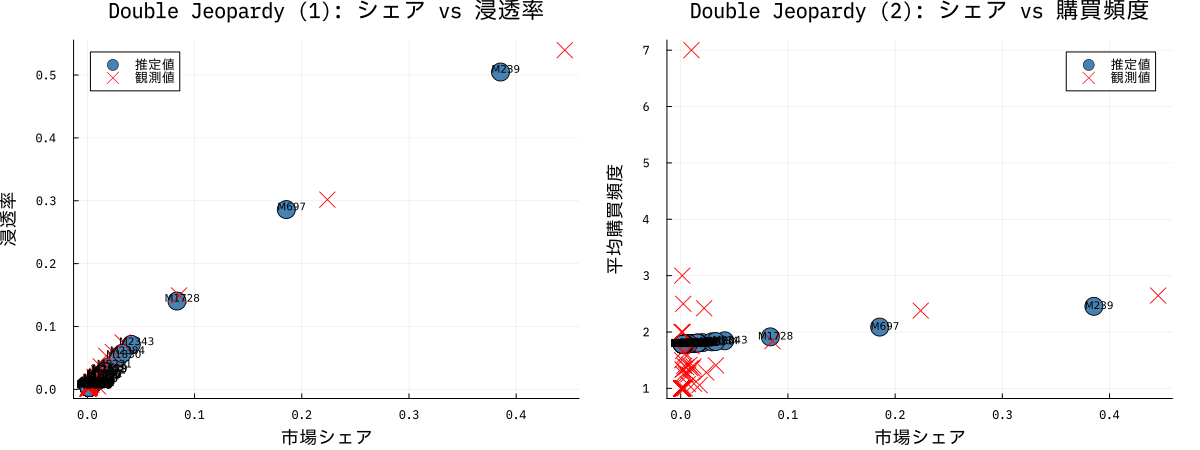

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\BASS_Dirichletモデル探索\\beer_20_30_double_jeopardy.png"

In [26]:
# Double Jeopardy: シェアが小さいブランドは浸透率も購買頻度も低い

# シェア vs 浸透率
p4 = scatter(p_est, pen_est;
    label="推定値", marker=:circle, markersize=10, color=:steelblue,
    xlabel="市場シェア", ylabel="浸透率",
    title="Double Jeopardy (1): シェア vs 浸透率")
scatter!(p4, share_obs, pen_obs;
    label="観測値", marker=:xcross, markersize=8, color=:red)
for j in 1:J
    annotate!(p4, p_est[j]+0.005, pen_est[j]+0.005,
              text(brands[j], 7))
end

# シェア vs 購買頻度
p5 = scatter(p_est, freq_est;
    label="推定値", marker=:circle, markersize=10, color=:steelblue,
    xlabel="市場シェア", ylabel="平均購買頻度",
    title="Double Jeopardy (2): シェア vs 購買頻度")
scatter!(p5, share_obs, freq_obs;
    label="観測値", marker=:xcross, markersize=8, color=:red)
for j in 1:J
    annotate!(p5, p_est[j]+0.005, freq_est[j]+0.02,
              text(brands[j], 7))
end

p45=plot(p4, p5; layout=(1,2), size=(1200, 450))
display(p45) ; savefig(p45, "beer_20_30_double_jeopardy.png")


## 12. ブランド間競合分析（重複購買）

In [27]:
# ブランド間重複購買率マトリクス
# D(i,j) = ブランドi購買者のうちブランドjも購買した割合
dup_matrix = zeros(J, J)
for i in 1:J
    buyers_i = brand_counts_data[:, i] .> 0
    n_buyers_i = sum(buyers_i)
    if n_buyers_i > 0
        for j in 1:J
            dup_matrix[i, j] = mean(brand_counts_data[buyers_i, j] .> 0)
        end
    end
end

df_dup = DataFrame(dup_matrix, Symbol.(brands))
insertcols!(df_dup, 1, :ブランド => brands)

# 数値を丸める
for col in names(df_dup)[2:end]
    df_dup[!, col] = round.(df_dup[!, col], digits=3)
end

println("=== 重複購買率マトリクス ===")
println("D(i,j) = ブランドi購買者がブランドjも買う確率")
df_dup

=== 重複購買率マトリクス ===
D(i,j) = ブランドi購買者がブランドjも買う確率


Row,ブランド,M2343,M239,M1728,M2431,M697,M5221,M779,M1830,M1767,M5881,M2387,M2398,M1649,M1629,M2232,M2427,M1920,M40,M5209,M1465,M352,M2384,M5392,M1560,M1367,M6361,M323,M2572,M2390,M5728,M2558,M176,M1283,M1396,M2466,M5981,M301,M5751,M2579,M5971,M2478,M2426,M6119,M5298,M2,M2693,M5120,M5284,M2468,M859,M5483,M2556,M2485,M2588
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,M2343,1.0,0.429,0.265,0.082,0.224,0.02,0.0,0.061,0.0,0.0,0.0,0.041,0.02,0.0,0.0,0.041,0.0,0.0,0.0,0.02,0.0,0.041,0.02,0.02,0.041,0.0,0.0,0.0,0.0,0.0,0.041,0.0,0.0,0.02,0.02,0.0,0.02,0.0,0.0,0.02,0.02,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M239,0.059,1.0,0.105,0.014,0.181,0.017,0.0,0.031,0.006,0.006,0.011,0.006,0.014,0.014,0.023,0.008,0.0,0.006,0.003,0.017,0.0,0.054,0.008,0.008,0.017,0.0,0.0,0.003,0.006,0.0,0.011,0.006,0.003,0.008,0.0,0.003,0.003,0.0,0.003,0.0,0.006,0.003,0.0,0.0,0.003,0.0,0.0,0.006,0.003,0.003,0.0,0.0,0.0,0.0
3,M1728,0.133,0.378,1.0,0.031,0.204,0.02,0.0,0.092,0.01,0.0,0.01,0.01,0.02,0.02,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.061,0.01,0.041,0.02,0.01,0.01,0.0,0.0,0.0,0.041,0.02,0.01,0.02,0.0,0.0,0.0,0.0,0.01,0.0,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0
4,M2431,0.235,0.294,0.176,1.0,0.294,0.0,0.0,0.0,0.118,0.059,0.0,0.0,0.0,0.059,0.0,0.059,0.059,0.0,0.0,0.0,0.0,0.059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.059,0.0,0.059,0.0,0.0,0.0,0.059,0.059,0.059,0.0,0.0,0.0,0.0,0.059,0.059
5,M697,0.056,0.323,0.101,0.025,1.0,0.02,0.005,0.056,0.015,0.005,0.0,0.01,0.005,0.045,0.025,0.005,0.005,0.0,0.005,0.005,0.005,0.035,0.01,0.01,0.025,0.01,0.0,0.0,0.005,0.0,0.015,0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.005,0.01,0.01,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.01,0.0,0.0,0.0,0.0,0.0
6,M5221,0.042,0.25,0.083,0.0,0.167,1.0,0.0,0.0,0.0,0.0,0.042,0.0,0.042,0.0,0.042,0.0,0.0,0.0,0.0,0.0,0.0,0.042,0.0,0.042,0.0,0.042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,M779,0.0,0.0,0.0,0.0,0.333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,M1830,0.086,0.314,0.257,0.0,0.314,0.0,0.0,1.0,0.0,0.0,0.086,0.057,0.029,0.057,0.029,0.029,0.0,0.029,0.0,0.029,0.0,0.029,0.0,0.029,0.057,0.0,0.0,0.0,0.029,0.0,0.057,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.029,0.029,0.0,0.0,0.0,0.0,0.0,0.029,0.029,0.029,0.0,0.0,0.0,0.0
9,M1767,0.0,0.25,0.125,0.25,0.375,0.0,0.0,0.0,1.0,0.125,0.125,0.0,0.0,0.0,0.0,0.0,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.125,0.0,0.125,0.0,0.0,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.125,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


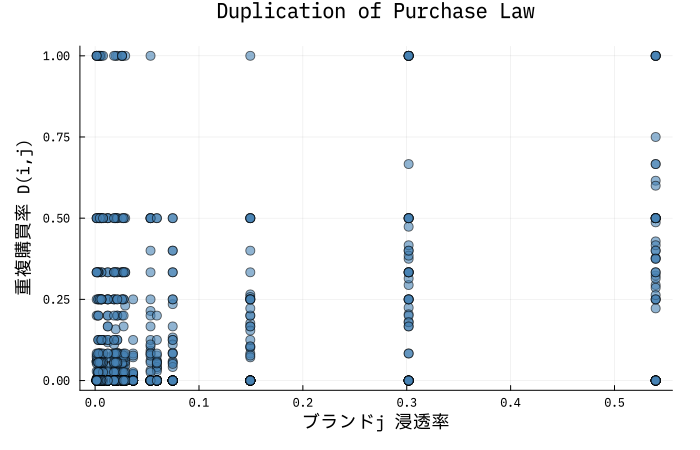

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\BASS_Dirichletモデル探索\\beer_20_30_duplication_law.png"

In [28]:
# Duplication of Purchase Law: D(i,j) ≈ b_j / D_coeff
# 理論的にはブランドjの浸透率に比例

# 対角要素を除いた重複率 vs 浸透率
dup_off_diag = []
pen_for_dup  = []
for i in 1:J
    for j in 1:J
        if i != j
            push!(dup_off_diag, dup_matrix[i, j])
            push!(pen_for_dup, pen_obs[j])
        end
    end
end

p_dup = scatter(pen_for_dup, dup_off_diag;
    xlabel="ブランドj 浸透率", ylabel="重複購買率 D(i,j)",
    title="Duplication of Purchase Law",
    label="", color=:steelblue, alpha=0.6, markersize=5,
    size=(700, 450))
display(p_dup) ; savefig(p_dup,"beer_20_30_duplication_law.png")


## 13. まとめ

In [21]:
println("="^60)
println("  Beer NBD-Dirichlet 分析結果サマリ (Week 20-30)")
println("="^60)
@printf("\nデータ: dunnhumby Beer/Ale Week20-30 (%d 消費者, %d ブランド, %d 購買)\n",
    N_consumers, J, total_purchases)
@printf("\n--- 推定パラメータ ---\n")
@printf("  M (カテゴリ平均購買回数) = %.3f\n", M_est)
@printf("  K (NBD 集約)            = %.3f\n", K_est)
@printf("  S (Dirichlet 集約)      = %.3f\n", S_est)
@printf("\n--- カテゴリ指標 ---\n")
@printf("  浸透率:     観測=%.3f  推定=%.3f\n", B_obs, B_est)
@printf("  購買頻度:   観測=%.2f  推定=%.2f（購買者のみ）\n",
    mean(n_cat_data[cat_buyers]), M_est / B_est)

println("\n--- 市場シェア（上位5） ---")
order = sortperm(p_est, rev=true)
for j in order[1:min(5, J)]
    @printf("  %-8s  観測=%.1f%%  推定=%.1f%%\n",
        brands[j], share_obs[j]*100, p_est[j]*100)
end

println("\n--- Double Jeopardy ---")
println("  小シェアブランドほど浸透率・購買頻度が低い傾向を確認")
println("\n保存ファイル:")
for f in filter(x -> startswith(x, "beer_20_30_") && endswith(x, ".png"), readdir("."))
    println("  ", f)
end

  Beer NBD-Dirichlet 分析結果サマリ (Week 20-30)

データ: dunnhumby Beer/Ale Week20-30 (656 消費者, 54 ブランド, 2104 購買)

--- 推定パラメータ ---
  M (カテゴリ平均購買回数) = 3.216
  K (NBD 集約)            = 1.841
  S (Dirichlet 集約)      = 1.662

--- カテゴリ指標 ---
  浸透率:     観測=1.000  推定=0.844
  購買頻度:   観測=3.21  推定=3.81（購買者のみ）

--- 市場シェア（上位5） ---
  M239      観測=44.5%  推定=38.5%
  M697      観測=22.4%  推定=18.6%
  M1728     観測=8.6%  推定=8.4%
  M2343     観測=3.3%  推定=4.1%
  M2384     観測=2.4%  推定=3.3%

--- Double Jeopardy ---
  小シェアブランドほど浸透率・購買頻度が低い傾向を確認

保存ファイル:
  beer_20_30_NBD_fit.png
  beer_20_30_double_jeopardy.png
  beer_20_30_duplication_law.png
  beer_20_30_param_posterior.png
  beer_20_30_pen_freq_compare.png
